In [2]:
# ── Block 1: Imports & polished plotting theme ──────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Brand palette — tweak to taste
BRAND = {
    "primary":  "#1D9E75",   # green  (approved / repaid)
    "danger":   "#E24B4A",   # red    (default)
    "accent":   "#378ADD",   # blue
    "amber":    "#EF9F27",
    "ink":      "#2C2C2A",
    "muted":    "#888780",
}
PALETTE = [BRAND["primary"], BRAND["danger"], BRAND["accent"],
           BRAND["amber"], "#7F77DD", "#D85A30"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize":      (9, 5),
    "figure.dpi":          110,
    "savefig.dpi":         150,
    "savefig.bbox":        "tight",
    "font.size":           11,
    "axes.titlesize":      14,
    "axes.titleweight":    "bold",
    "axes.titlecolor":     BRAND["ink"],
    "axes.labelcolor":     BRAND["ink"],
    "axes.edgecolor":      "#D3D1C7",
    "axes.grid":           True,
    "grid.color":          "#ECEAE3",
    "axes.axisbelow":      True,
})

FIG_DIR = "figures"
import os; os.makedirs(FIG_DIR, exist_ok=True)

print("Setup complete. Palette loaded, figures/ ready.")

Setup complete. Palette loaded, figures/ ready.


In [3]:
# ── Block 2: Load data & first look ─────────────────────────────────────
DATA_PATH = "data/raw/ph_motorcycle_loans.csv"   # adjust path if different

df = pd.read_csv(DATA_PATH)

# Parse the date columns if present (label-latency fields)
for col in ["loan_origination_date", "label_determination_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("Columns:")
print(list(df.columns))

df.head()

Shape: 5,000 rows × 31 columns

Columns:
['loan_account_no', 'product_description', 'loan_origination_date', 'bureau_score', 'down_payment_amount', 'branch_name', 'res_years_at_current_city', 'res_years_at_current_address', 'interest_rate', 'loan_asset_cost', 'gender', 'channel', 'age', 'number_of_installments', 'res_city', 'res_province', 'total_income', 'asset_model', 'industry', 'nature_of_business', 'marital_status', 'manufacturer', 'occupation_type', 'res_resident_status', 'years_in_occupation', 'has_existing_loan', 'number_of_dependents', 'days_past_due', 'label_determination_date', 'label_is_mature', 'TARGET']


,loan_account_no,product_description,loan_origination_date,bureau_score,down_payment_amount,branch_name,res_years_at_current_city,res_years_at_current_address,interest_rate,loan_asset_cost,gender,channel,age,number_of_installments,res_city,res_province,total_income,asset_model,industry,nature_of_business,marital_status,manufacturer,occupation_type,res_resident_status,years_in_occupation,has_existing_loan,number_of_dependents,days_past_due,label_determination_date,label_is_mature,TARGET
0,PH12638242648613819894,Motorcycle Loan,2024-07-04,707,9000,Cubao QC,20,0,14.75,86023,Female,DIRECT,38,18,Quezon City,Metro Manila,8466,TMX 125 Alpha,Transport,Services,Married,Honda,Tricycle/Jeepney Driver,Owned,11,Yes,3,0,2025-01-19,True,0
1,PH11479880868707720722,Motorcycle Loan,2024-06-09,770,8500,Quiapo Manila,1,1,24.59,71021,Male,DIRECT,25,24,Manila,Metro Manila,11152,TMX 125 Alpha,Transport,Services,Live-in,Honda,Tricycle/Jeepney Driver,Owned,7,Yes,3,25,2024-12-25,True,0
2,PH16033466362519845396,Motorcycle Loan,2024-07-13,653,14000,Iloilo,2,0,15.56,105222,Male,DEALER,58,24,Iloilo City,Iloilo,16392,Sniper 150,Manufacturing,Manufacturing,Widowed/Separated,Yamaha,Other Self Employed,Rented,4,No,4,136,2024-11-11,True,1
3,PH10115640021495636705,Motorcycle Loan,2026-03-15,721,11000,Cagayan de Oro,23,8,15.16,75530,Male,DEALER,44,18,Cagayan de Oro,Misamis Oriental,20867,NMAX 155,Retail,Trading,Single,Yamaha,Sari-sari Store Owner,Living with Parents,19,Yes,4,1,2026-09-09,False,0
4,PH19269830104468822237,Motorcycle Loan,2026-01-04,696,13500,Cubao QC,19,6,21.23,85708,Male,DIRECT,28,36,Quezon City,Metro Manila,37671,Barako II 175,Remittance-dependent,Services,Married,Kawasaki,OFW Dependent,Owned,6,No,0,0,2026-06-03,True,0


In [4]:
# ── Block 3: Data quality & label integrity ─────────────────────────────
print("── Missing values ──")
missing = df.isna().sum()
print(missing[missing > 0] if missing.any() else "None ✓")

print("\n── Dtypes ──")
print(df.dtypes)

print("\n── Duplicate loan_account_no ──")
print(f"{df['loan_account_no'].duplicated().sum()} duplicates")

# Label integrity: TARGET must equal (days_past_due >= 90)
consistent = (df["TARGET"] == (df["days_past_due"] >= 90)).all()
print(f"\n── Label integrity (TARGET == days_past_due ≥ 90) ──\n{'PASS ✓' if consistent else 'FAIL ✗'}")

# Latency sanity: determination date must be on/after origination
if {"label_determination_date", "loan_origination_date"}.issubset(df.columns):
    valid_dates = (df["label_determination_date"] >= df["loan_origination_date"]).all()
    print(f"\n── Date order (determination ≥ origination) ──\n{'PASS ✓' if valid_dates else 'FAIL ✗'}")

# years_in_occupation must be <= age - 18
occ_ok = (df["years_in_occupation"] <= df["age"] - 18).all()
print(f"\n── years_in_occupation ≤ age−18 ──\n{'PASS ✓' if occ_ok else 'FAIL ✗'}")

── Missing values ──
None ✓

── Dtypes ──
loan_account_no                         object
product_description                     object
loan_origination_date           datetime64[ns]
bureau_score                             int64
down_payment_amount                      int64
branch_name                             object
res_years_at_current_city                int64
res_years_at_current_address             int64
interest_rate                          float64
loan_asset_cost                          int64
gender                                  object
channel                                 object
age                                      int64
number_of_installments                   int64
res_city                                object
res_province                            object
total_income                             int64
asset_model                             object
industry                                object
nature_of_business                      object
marital_status    

Total loans:        5,000
Matured (known):    3,934  (78.7%)
Pending (latency):  1,066  (21.3%)

Default rate (all rows, naive):     27.66%
Default rate (matured only, honest): 29.28%


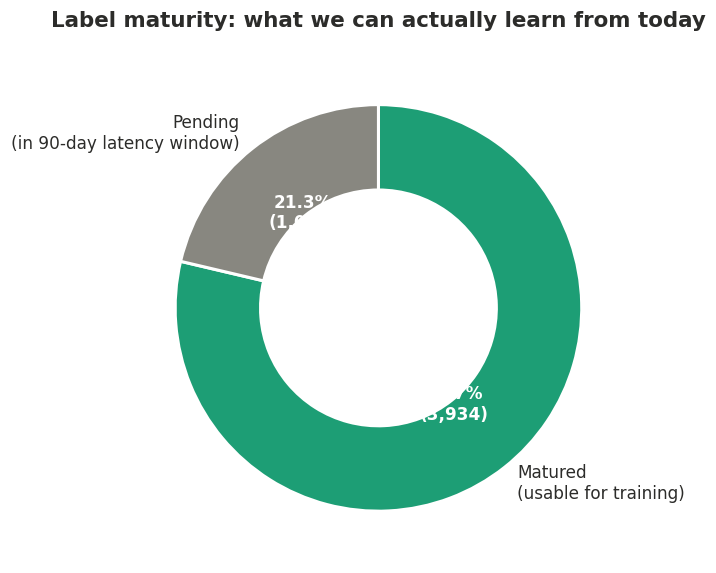

In [5]:
# ── Block 4: Label maturity — the latency window ────────────────────────
n_total   = len(df)
n_mature  = int(df["label_is_mature"].sum())
n_pending = n_total - n_mature

print(f"Total loans:        {n_total:,}")
print(f"Matured (known):    {n_mature:,}  ({n_mature/n_total:.1%})")
print(f"Pending (latency):  {n_pending:,}  ({n_pending/n_total:.1%})")

# Default rate — overall vs matured-only (the honest one)
overall_dr = df["TARGET"].mean()
mature_dr  = df.loc[df["label_is_mature"], "TARGET"].mean()
print(f"\nDefault rate (all rows, naive):     {overall_dr:.2%}")
print(f"Default rate (matured only, honest): {mature_dr:.2%}")

# Visual: donut of maturity split
fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(
    [n_mature, n_pending],
    labels=["Matured\n(usable for training)", "Pending\n(in 90-day latency window)"],
    colors=[BRAND["primary"], BRAND["muted"]],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100*n_total)):,})",
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    textprops=dict(color=BRAND["ink"], fontsize=11),
)
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold")
ax.set_title("Label maturity: what we can actually learn from today", pad=18)
plt.savefig(f"{FIG_DIR}/01_label_maturity.png")
plt.show()

Modeling frame: 3,934 matured loans

TARGET
0    2782
1    1152

Imbalance ratio (neg/pos): 2.41  → use as scale_pos_weight ≈ 2.4


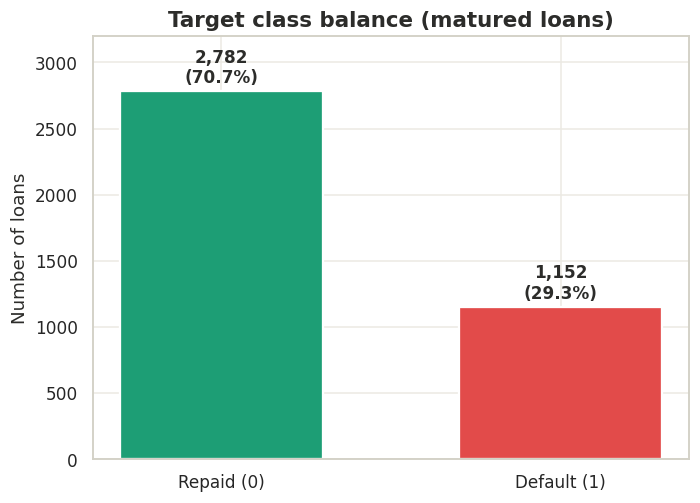

In [6]:
# ── Block 5: Matured-only modeling frame + class balance ────────────────
# Everything involving TARGET uses this frame — we only learn from
# loans whose D3 outcome is actually observable today.
model_df = df[df["label_is_mature"]].copy().reset_index(drop=True)
print(f"Modeling frame: {len(model_df):,} matured loans\n")

counts = model_df["TARGET"].value_counts().sort_index()
labels = ["Repaid (0)", "Default (1)"]
imbalance_ratio = counts[0] / counts[1]
print(counts.to_string())
print(f"\nImbalance ratio (neg/pos): {imbalance_ratio:.2f}  "
      f"→ use as scale_pos_weight ≈ {imbalance_ratio:.1f}")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts.values,
              color=[BRAND["primary"], BRAND["danger"]],
              edgecolor="white", linewidth=1.5, width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 30,
            f"{v:,}\n({v/len(model_df):.1%})",
            ha="center", va="bottom", fontweight="bold", color=BRAND["ink"])
ax.set_title("Target class balance (matured loans)")
ax.set_ylabel("Number of loans")
ax.set_ylim(0, counts.max() * 1.15)
ax.margins(y=0.1)
plt.savefig(f"{FIG_DIR}/02_class_balance.png")
plt.show()

                         default_rate     n
occupation_type                            
Employed                         20.0   539
OFW Dependent                    25.0   432
Construction Worker              26.9   628
Sari-sari Store Owner            27.3   750
Other Self Employed              29.6   389
Tricycle/Jeepney Driver          37.4  1196


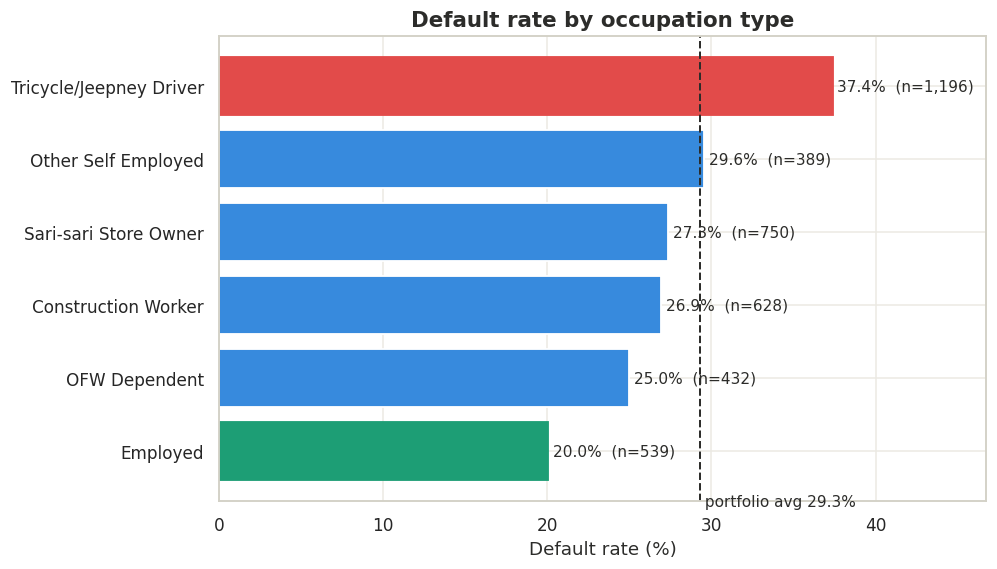

In [7]:
# ── Block 6: Default rate by occupation type ────────────────────────────
occ = (model_df.groupby("occupation_type")["TARGET"]
       .agg(default_rate="mean", n="count")
       .sort_values("default_rate", ascending=True))
print(occ.assign(default_rate=lambda d: (d["default_rate"]*100).round(1)).to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(occ.index, occ["default_rate"]*100,
               color=BRAND["accent"], edgecolor="white", linewidth=1.2)

# Color the worst performer red, the best green
bars[0].set_color(BRAND["primary"])      # lowest default
bars[-1].set_color(BRAND["danger"])      # highest default

overall = model_df["TARGET"].mean()*100
ax.axvline(overall, color=BRAND["ink"], linestyle="--", linewidth=1.3)
ax.text(overall, -0.6, f" portfolio avg {overall:.1f}%",
        color=BRAND["ink"], fontsize=10, va="top")

for b, v, n in zip(bars, occ["default_rate"]*100, occ["n"]):
    ax.text(v + 0.3, b.get_y() + b.get_height()/2,
            f"{v:.1f}%  (n={n:,})", va="center", fontsize=10, color=BRAND["ink"])

ax.set_title("Default rate by occupation type")
ax.set_xlabel("Default rate (%)")
ax.set_xlim(0, (occ["default_rate"].max()*100) * 1.25)
plt.savefig(f"{FIG_DIR}/03_default_by_occupation.png")
plt.show()

                 default_rate     n
bureau_bucket                      
No history (-1)          42.8  1576
550–599                  26.7   516
600–649                  24.3   515
650–699                  19.4   501
700–749                  15.7   503
750–780                  11.8   323


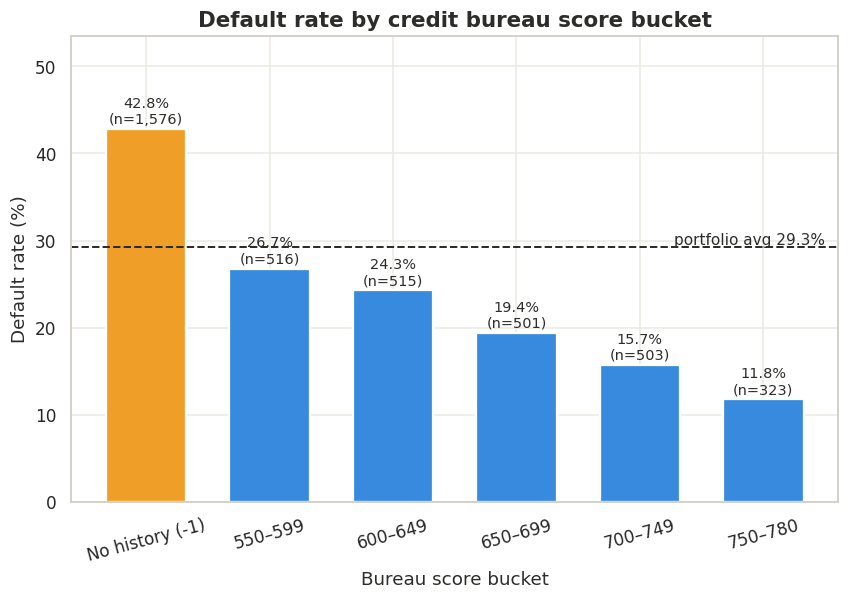

In [8]:
# ── Block 7: Default rate by bureau score bucket ────────────────────────
def bureau_bucket(s):
    if s == -1:        return "No history (-1)"
    if s < 600:        return "550–599"
    if s < 650:        return "600–649"
    if s < 700:        return "650–699"
    if s < 750:        return "700–749"
    return "750–780"

model_df["bureau_bucket"] = model_df["bureau_score"].apply(bureau_bucket)

order = ["No history (-1)", "550–599", "600–649", "650–699", "700–749", "750–780"]
bk = (model_df.groupby("bureau_bucket")["TARGET"]
      .agg(default_rate="mean", n="count")
      .reindex(order))
print(bk.assign(default_rate=lambda d: (d["default_rate"]*100).round(1)).to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [BRAND["amber"]] + [BRAND["accent"]]*5   # highlight the -1 bucket
bars = ax.bar(bk.index, bk["default_rate"]*100,
              color=colors, edgecolor="white", linewidth=1.5, width=0.65)

overall = model_df["TARGET"].mean()*100
ax.axhline(overall, color=BRAND["ink"], linestyle="--", linewidth=1.3)
ax.text(len(order)-0.5, overall+0.3, f"portfolio avg {overall:.1f}%",
        ha="right", color=BRAND["ink"], fontsize=10)

for b, v, n in zip(bars, bk["default_rate"]*100, bk["n"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.3,
            f"{v:.1f}%\n(n={n:,})", ha="center", va="bottom",
            fontsize=9.5, color=BRAND["ink"])

ax.set_title("Default rate by credit bureau score bucket")
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Bureau score bucket")
ax.set_ylim(0, (bk["default_rate"].max()*100)*1.25)
plt.xticks(rotation=15)
plt.savefig(f"{FIG_DIR}/04_default_by_bureau.png")
plt.show()

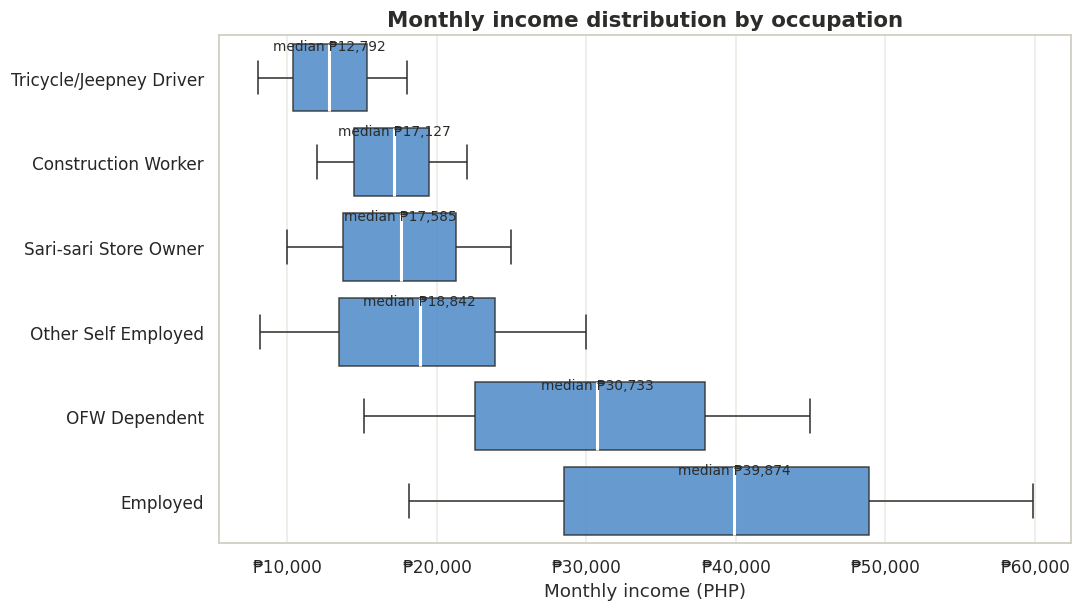

In [9]:
# ── Block 8: Income distribution by occupation ──────────────────────────
# Order occupations by median income for a clean read
order_inc = (model_df.groupby("occupation_type")["total_income"]
             .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=model_df, x="total_income", y="occupation_type",
    order=order_inc, ax=ax,
    color=BRAND["accent"], fliersize=2,
    boxprops=dict(alpha=0.85, edgecolor=BRAND["ink"]),
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color=BRAND["ink"]),
    capprops=dict(color=BRAND["ink"]),
)
ax.set_title("Monthly income distribution by occupation")
ax.set_xlabel("Monthly income (PHP)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₱{x:,.0f}"))

# Annotate median at the right edge of each box
for i, occ_name in enumerate(order_inc):
    med = model_df.loc[model_df["occupation_type"] == occ_name, "total_income"].median()
    ax.text(med, i - 0.32, f"median ₱{med:,.0f}",
            fontsize=9, color=BRAND["ink"], ha="center")

plt.savefig(f"{FIG_DIR}/05_income_by_occupation.png")
plt.show()

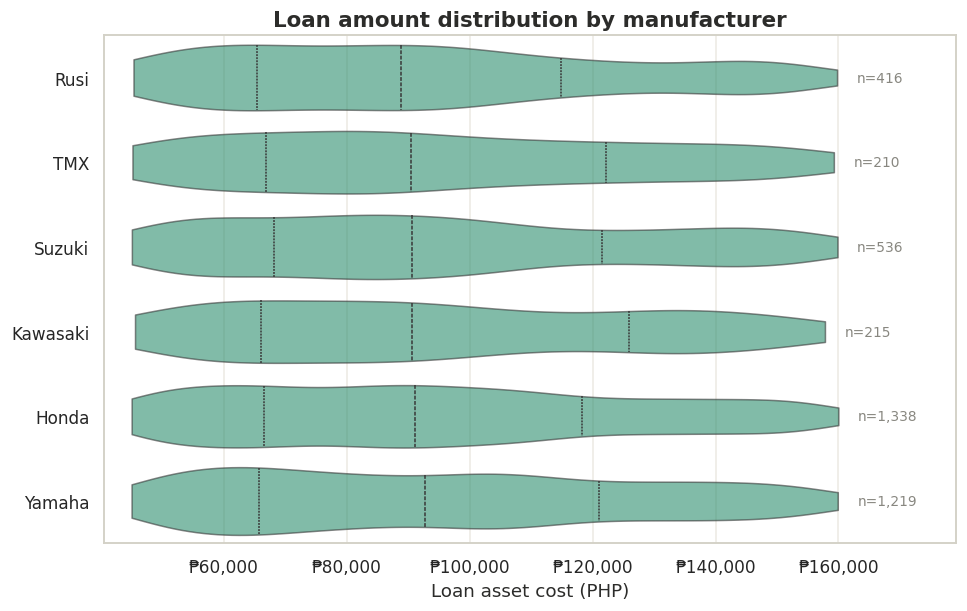

In [10]:
# ── Block 9: Loan amount distribution by manufacturer ───────────────────
order_mfr = (model_df.groupby("manufacturer")["loan_asset_cost"]
             .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=model_df, x="loan_asset_cost", y="manufacturer",
    order=order_mfr, ax=ax, cut=0, inner="quartile",
    color=BRAND["primary"], linewidth=1,
)
for coll in ax.collections:
    coll.set_alpha(0.6)

ax.set_title("Loan amount distribution by manufacturer")
ax.set_xlabel("Loan asset cost (PHP)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₱{x:,.0f}"))

# Median count + amount annotation on the right
for i, m in enumerate(order_mfr):
    sub = model_df.loc[model_df["manufacturer"] == m, "loan_asset_cost"]
    ax.text(sub.max()*1.02, i, f"n={len(sub):,}",
            va="center", fontsize=9, color=BRAND["muted"])

ax.set_xlim(model_df["loan_asset_cost"].min()*0.9,
            model_df["loan_asset_cost"].max()*1.12)
plt.savefig(f"{FIG_DIR}/06_loan_by_manufacturer.png")
plt.show()

Loan-to-income ratio — overall stats
count    3934.00
mean        5.68
std         3.13
min         0.79
25%         3.37
50%         4.99
75%         7.40
max        18.93

Default rate by loan-to-income bucket
            default_rate_%     n
lti_bucket                      
≤3×                   19.9   788
3–5×                  20.5  1182
5–7×                  27.5   850
7–10×                 40.1   724
>10×                  58.7   390

Portfolio avg default rate: 29.3%


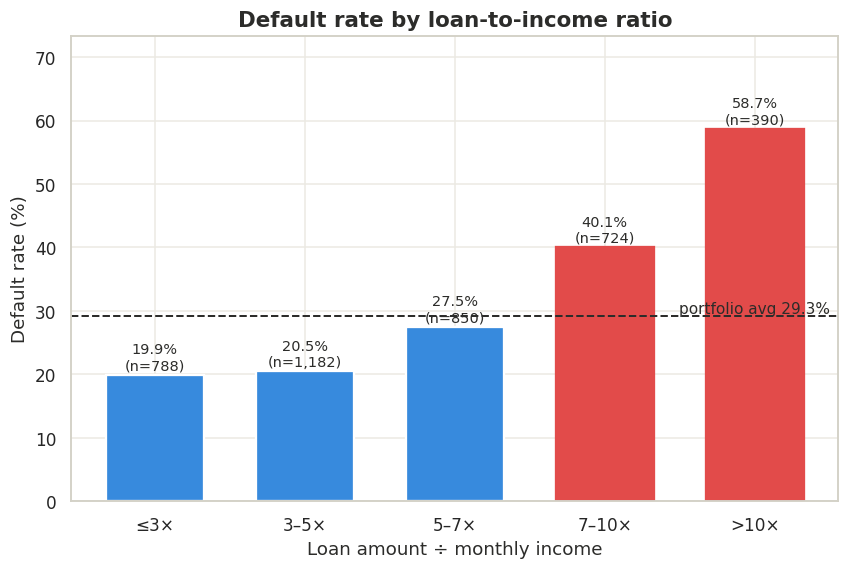

In [11]:
# ── Block 9b: Loan-to-income ratio vs default ───────────────────────────
# Engineered feature — likely the strongest single predictor.
model_df["loan_to_income_ratio"] = (
    model_df["loan_asset_cost"] / model_df["total_income"]
)

# Bucket the ratio into interpretable bands
bins   = [0, 3, 5, 7, 10, np.inf]
labels = ["≤3×", "3–5×", "5–7×", "7–10×", ">10×"]
model_df["lti_bucket"] = pd.cut(model_df["loan_to_income_ratio"],
                                bins=bins, labels=labels)

lti = (model_df.groupby("lti_bucket")["TARGET"]
       .agg(default_rate="mean", n="count"))

# ── TEXT OUTPUT ──
print("Loan-to-income ratio — overall stats")
print(model_df["loan_to_income_ratio"].describe().round(2).to_string())
print("\nDefault rate by loan-to-income bucket")
print(lti.assign(default_rate=lambda d: (d["default_rate"]*100).round(1))
        .rename(columns={"default_rate": "default_rate_%"})
        .to_string())
print(f"\nPortfolio avg default rate: {model_df['TARGET'].mean()*100:.1f}%")

# ── PLOT ──
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(lti.index.astype(str), lti["default_rate"]*100,
              color=BRAND["accent"], edgecolor="white", linewidth=1.5, width=0.65)
# Redden buckets above portfolio average
avg = model_df["TARGET"].mean()*100
for b, v in zip(bars, lti["default_rate"]*100):
    if v > avg: b.set_color(BRAND["danger"])
ax.axhline(avg, color=BRAND["ink"], linestyle="--", linewidth=1.3)
ax.text(len(labels)-0.5, avg+0.3, f"portfolio avg {avg:.1f}%",
        ha="right", color=BRAND["ink"], fontsize=10)
for b, v, n in zip(bars, lti["default_rate"]*100, lti["n"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.3,
            f"{v:.1f}%\n(n={n:,})", ha="center", va="bottom",
            fontsize=9.5, color=BRAND["ink"])
ax.set_title("Default rate by loan-to-income ratio")
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Loan amount ÷ monthly income")
ax.set_ylim(0, (lti["default_rate"].max()*100)*1.25)
plt.savefig(f"{FIG_DIR}/06_default_by_lti.png")
plt.show()

Correlation with TARGET (sorted by absolute strength)
loan_to_income_ratio            0.272
bureau_score                   -0.254
loan_asset_cost                 0.155
total_income                   -0.140
down_payment_amount             0.133
number_of_dependents            0.082
years_in_occupation            -0.077
age                            -0.067
interest_rate                   0.048
res_years_at_current_address    0.029
res_years_at_current_city       0.016
number_of_installments          0.006


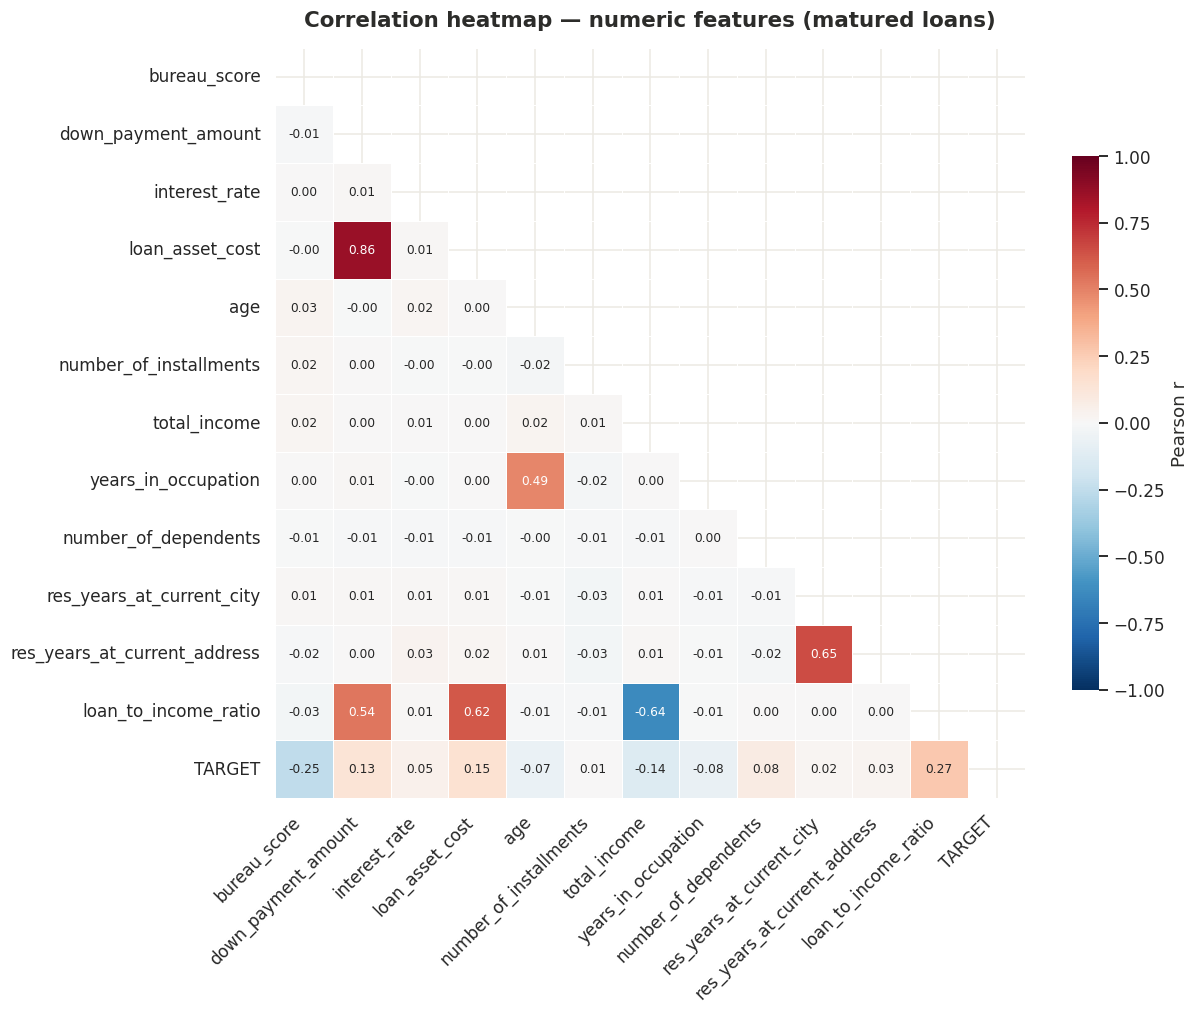

In [12]:
# ── Block 10: Correlation heatmap (numeric features) ────────────────────
num_cols = [
    "bureau_score", "down_payment_amount", "interest_rate", "loan_asset_cost",
    "age", "number_of_installments", "total_income", "years_in_occupation",
    "number_of_dependents", "res_years_at_current_city",
    "res_years_at_current_address", "loan_to_income_ratio", "TARGET",
]
corr = model_df[num_cols].corr()

# ── TEXT OUTPUT: correlations with TARGET, sorted ──
print("Correlation with TARGET (sorted by absolute strength)")
target_corr = (corr["TARGET"].drop("TARGET")
               .reindex(corr["TARGET"].drop("TARGET").abs()
                        .sort_values(ascending=False).index))
print(target_corr.round(3).to_string())

# ── PLOT ──
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    annot_kws={"size": 8}, ax=ax,
)
ax.set_title("Correlation heatmap — numeric features (matured loans)", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig(f"{FIG_DIR}/07_correlation_heatmap.png")
plt.show()

── Model metrics ──
  auc_roc     : 0.7698
  precision   : 0.4527
  recall      : 0.7696
  f1          : 0.5700
  accuracy    : 0.6607
  threshold   : 0.3500

── Threshold sensitivity ──
Threshold    Precision    Recall       F1        
0.25         0.4012       0.8913       0.5533    
0.30         0.4311       0.8435       0.5706    
0.35         0.4527       0.7696       0.5700     ← selected
0.40         0.4763       0.7000       0.5669    
0.45         0.5034       0.6478       0.5665    
0.50         0.5189       0.5957       0.5547    


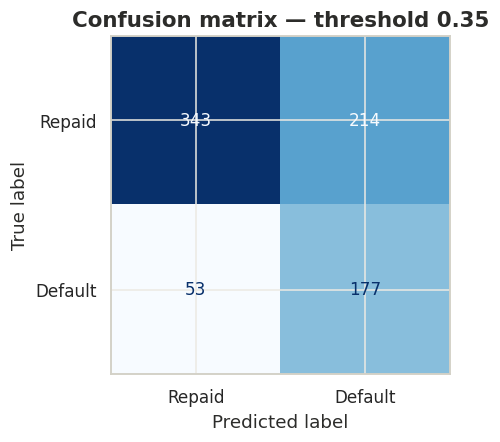

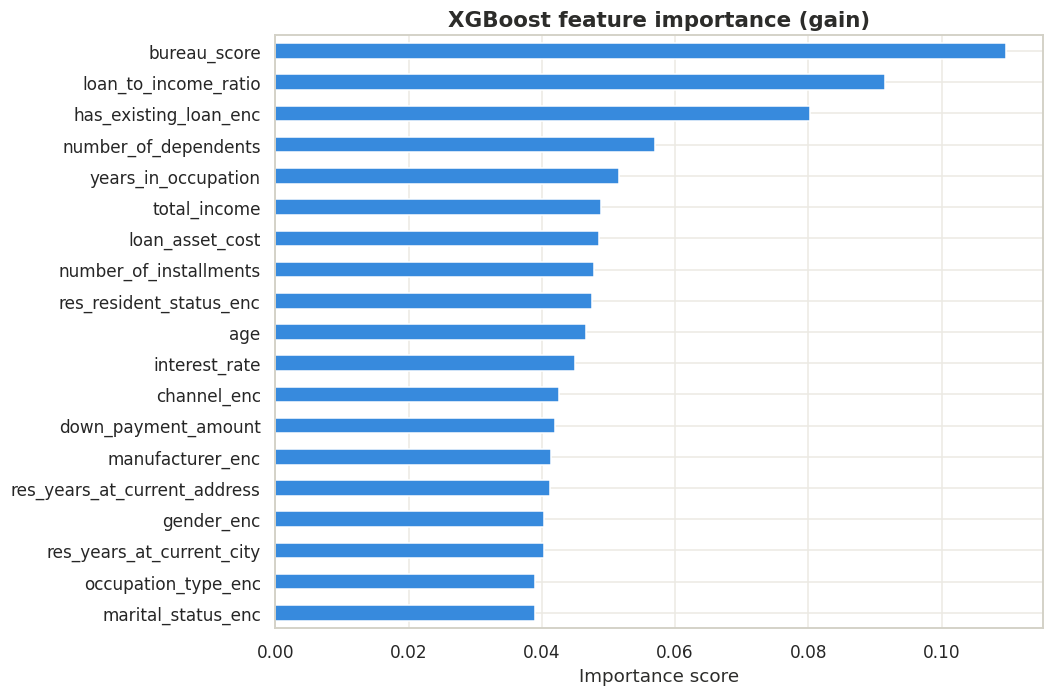

2026/06/04 21:11:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 21:12:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Run ID: cf8677ecf38048919e46635587ddbe63


In [14]:
# ── Block 12: XGBoost training with MLflow tracking ─────────────────────
import mlflow
import mlflow.xgboost
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
)
import pickle, os

MLFLOW_URI = "./mlruns"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("motorcycle-loan-default")

THRESHOLD = 0.35   # lower threshold = catch more defaulters

PARAMS = {
    "n_estimators":     500,
    "max_depth":        4,
    "learning_rate":    0.03,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "scale_pos_weight": imbalance_ratio,
    "base_score":       0.5,        # ← add this line
    "eval_metric":      "auc",
    "random_state":     42,
    "n_jobs":           -1,
}

with mlflow.start_run(run_name="xgboost_v1_baseline") as run:
    RUN_ID = run.info.run_id

    # ── Train ──
    model = xgb.XGBClassifier(**PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )

    # ── Evaluate ──
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred       = (y_pred_proba >= THRESHOLD).astype(int)

    metrics = {
        "auc_roc":   roc_auc_score(y_test, y_pred_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_test, y_pred),
        "threshold": THRESHOLD,
    }

    print("── Model metrics ──")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")

    # ── Threshold sensitivity ──
    print("\n── Threshold sensitivity ──")
    print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10}")
    for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
        yp = (y_pred_proba >= t).astype(int)
        p  = precision_score(y_test, yp, zero_division=0)
        r  = recall_score(y_test, yp, zero_division=0)
        f  = f1_score(y_test, yp, zero_division=0)
        marker = " ← selected" if t == THRESHOLD else ""
        print(f"{t:<12.2f} {p:<12.4f} {r:<12.4f} {f:<10.4f}{marker}")

    # ── Log to MLflow ──
    mlflow.log_params(PARAMS)
    mlflow.log_metrics({k: v for k, v in metrics.items() if k != "threshold"})
    mlflow.log_param("threshold", THRESHOLD)
    mlflow.log_param("feature_count", len(FEATURE_COLS))
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("test_rows", len(X_test))
    mlflow.log_param("dataset", "ph_synthetic_v1")
    mlflow.set_tag("stage", "baseline")

    # ── Confusion matrix ──
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Repaid", "Default"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion matrix — threshold {THRESHOLD}")
    cm_path = f"{FIG_DIR}/08_confusion_matrix.png"
    plt.savefig(cm_path)
    plt.show()
    mlflow.log_artifact(cm_path)

    # ── Feature importance ──
    fi = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    fig, ax = plt.subplots(figsize=(9, 7))
    fi.plot(kind="barh", ax=ax, color=BRAND["accent"], edgecolor="white")
    ax.set_title("XGBoost feature importance (gain)")
    ax.set_xlabel("Importance score")
    fi_path = f"{FIG_DIR}/09_feature_importance.png"
    plt.savefig(fi_path)
    plt.show()
    mlflow.log_artifact(fi_path)

    # ── Log model ──
    mlflow.xgboost.log_model(model, artifact_path="model")

    # ── Save encoders as artifact ──
    enc_path = f"{FIG_DIR}/encoders.pkl"
    with open(enc_path, "wb") as f:
        pickle.dump(encoders, f)
    mlflow.log_artifact(enc_path)

    print(f"\nRun ID: {RUN_ID}")

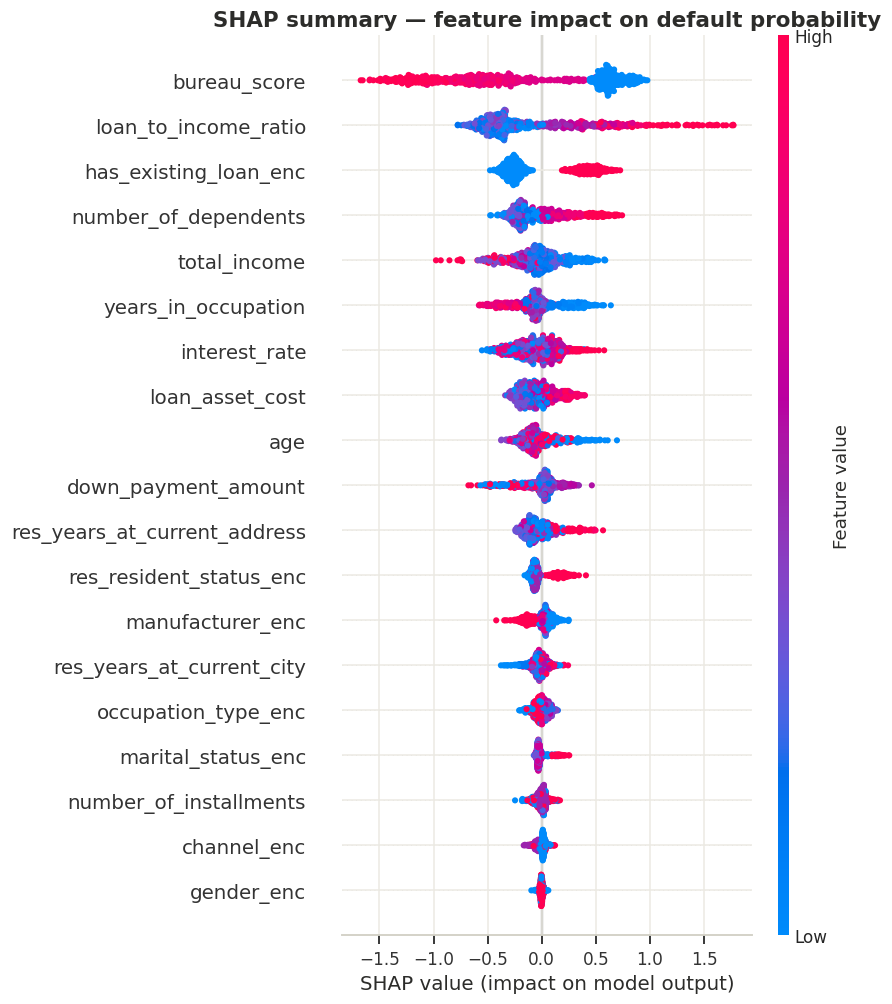

✓ Saved figures/10_shap_summary.png

Mang Tony default probability: 14.77%
Decision (0.35 threshold): APPROVED


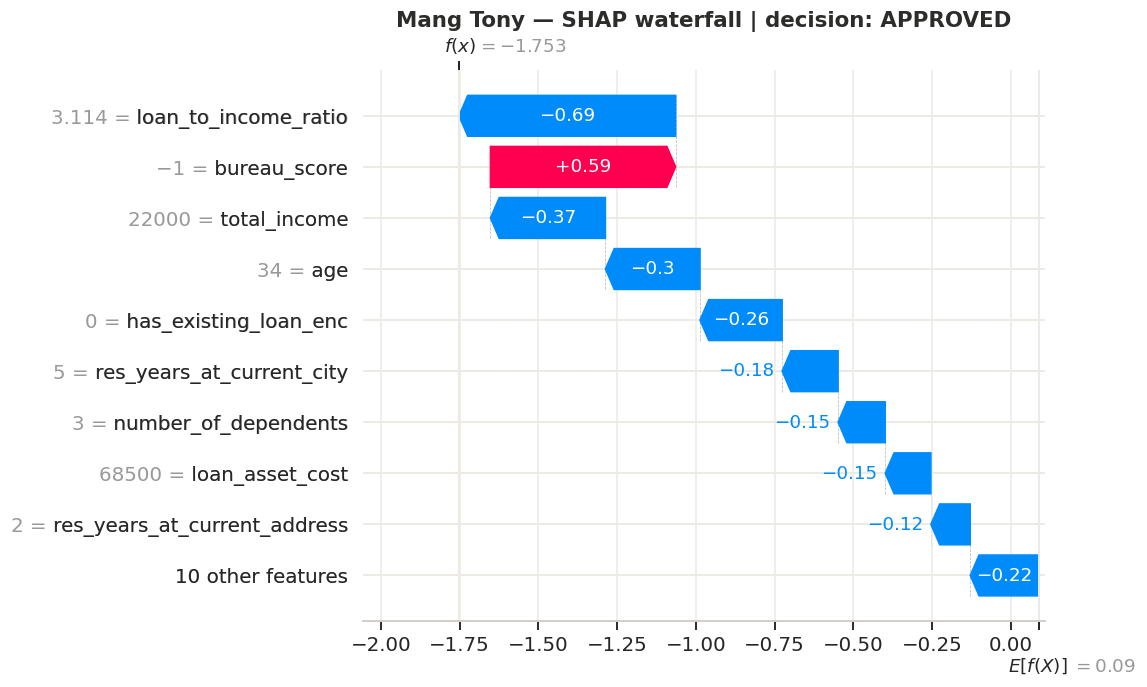

✓ Saved figures/11_mang_tony_waterfall.png


In [17]:
# ── Block 14: SHAP explainability ───────────────────────────────────────
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ── Summary plot ──
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    show=False,
)
plt.title("SHAP summary — feature impact on default probability")
shap_summary_path = f"{FIG_DIR}/10_shap_summary.png"
plt.savefig(shap_summary_path, bbox_inches="tight")
plt.show()
print(f"✓ Saved {shap_summary_path}")

# ── Mang Tony sample row ──
mang_tony_raw = {
    "bureau_score":               -1,
    "down_payment_amount":        9000,
    "interest_rate":              14.99,
    "loan_asset_cost":            68500,
    "age":                        34,
    "number_of_installments":     24,
    "total_income":               22000,
    "years_in_occupation":        6,
    "number_of_dependents":       3,
    "res_years_at_current_city":  5,
    "res_years_at_current_address": 2,
    "gender":                     "Male",
    "occupation_type":            "Tricycle/Jeepney Driver",
    "marital_status":             "Married",
    "res_resident_status":        "Living with Parents",
    "has_existing_loan":          "No",
    "manufacturer":               "Honda",
    "channel":                    "DEALER",
}

# ── Encode for model input ──
mang_tony_enc = {
    "bureau_score":                 mang_tony_raw["bureau_score"],
    "down_payment_amount":          mang_tony_raw["down_payment_amount"],
    "interest_rate":                mang_tony_raw["interest_rate"],
    "loan_asset_cost":              mang_tony_raw["loan_asset_cost"],
    "age":                          mang_tony_raw["age"],
    "number_of_installments":       mang_tony_raw["number_of_installments"],
    "total_income":                 mang_tony_raw["total_income"],
    "years_in_occupation":          mang_tony_raw["years_in_occupation"],
    "number_of_dependents":         mang_tony_raw["number_of_dependents"],
    "res_years_at_current_city":    mang_tony_raw["res_years_at_current_city"],
    "res_years_at_current_address": mang_tony_raw["res_years_at_current_address"],
    "loan_to_income_ratio":         mang_tony_raw["loan_asset_cost"] / mang_tony_raw["total_income"],
}
for col in encode_cols:
    le = encoders[col]
    val = mang_tony_raw[col]
    mang_tony_enc[col + "_enc"] = int(
        le.transform([val])[0] if val in le.classes_ else 0
    )

mang_tony_df = pd.DataFrame(
    [[mang_tony_enc[c] for c in FEATURE_COLS]],
    columns=FEATURE_COLS,
)

# ── Predict ──
tony_prob = model.predict_proba(mang_tony_df)[0][1]
tony_pred = "NEEDS REVIEW" if tony_prob >= THRESHOLD else "APPROVED"
tony_shap = explainer.shap_values(mang_tony_df)

print(f"\nMang Tony default probability: {tony_prob:.2%}")
print(f"Decision ({THRESHOLD} threshold): {tony_pred}")

# ── Waterfall plot ──
shap.plots.waterfall(
    shap.Explanation(
        values=tony_shap[0],
        base_values=explainer.expected_value,
        data=mang_tony_df.iloc[0].values,
        feature_names=FEATURE_COLS,
    ),
    show=False,
)
plt.title(f"Mang Tony — SHAP waterfall | decision: {tony_pred}")
waterfall_path = f"{FIG_DIR}/11_mang_tony_waterfall.png"
plt.savefig(waterfall_path, bbox_inches="tight")
plt.show()
print(f"✓ Saved {waterfall_path}")

In [20]:
# ── Block 11: Feature engineering + preprocessing ───────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

if "loan_to_income_ratio" not in model_df.columns:
    model_df["loan_to_income_ratio"] = (
        model_df["loan_asset_cost"] / model_df["total_income"]
    )

encoders = {}
encode_cols = [
    "gender", "occupation_type", "marital_status",
    "res_resident_status", "has_existing_loan", "manufacturer", "channel",
]
for col in encode_cols:
    le = LabelEncoder()
    model_df[col + "_enc"] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

FEATURE_COLS = [
    "bureau_score", "down_payment_amount", "interest_rate", "loan_asset_cost",
    "age", "number_of_installments", "total_income", "years_in_occupation",
    "number_of_dependents", "res_years_at_current_city",
    "res_years_at_current_address", "loan_to_income_ratio",
    "gender_enc", "occupation_type_enc", "marital_status_enc",
    "res_resident_status_enc", "has_existing_loan_enc",
    "manufacturer_enc", "channel_enc",
]
TARGET_COL = "TARGET"

X = model_df[FEATURE_COLS]
y = model_df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"XGBoost version: {xgb.__version__}")
print(f"Training set: {len(X_train):,} | Test set: {len(X_test):,}")
print(f"scale_pos_weight: {imbalance_ratio:.2f}")

XGBoost version: 2.1.1
Training set: 3,147 | Test set: 787
scale_pos_weight: 2.41


2026/06/04 21:15:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


── Model metrics ──
  auc_roc     : 0.7698
  precision   : 0.4527
  recall      : 0.7696
  f1          : 0.5700
  accuracy    : 0.6607


2026/06/04 21:15:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


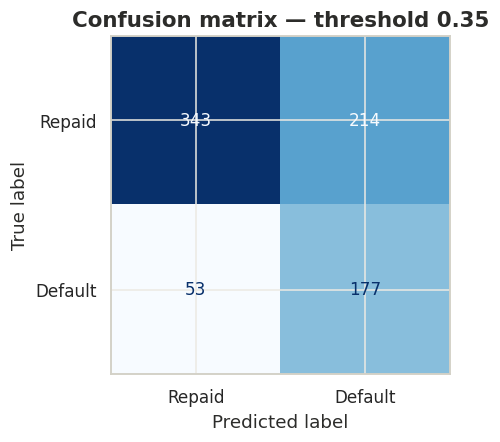

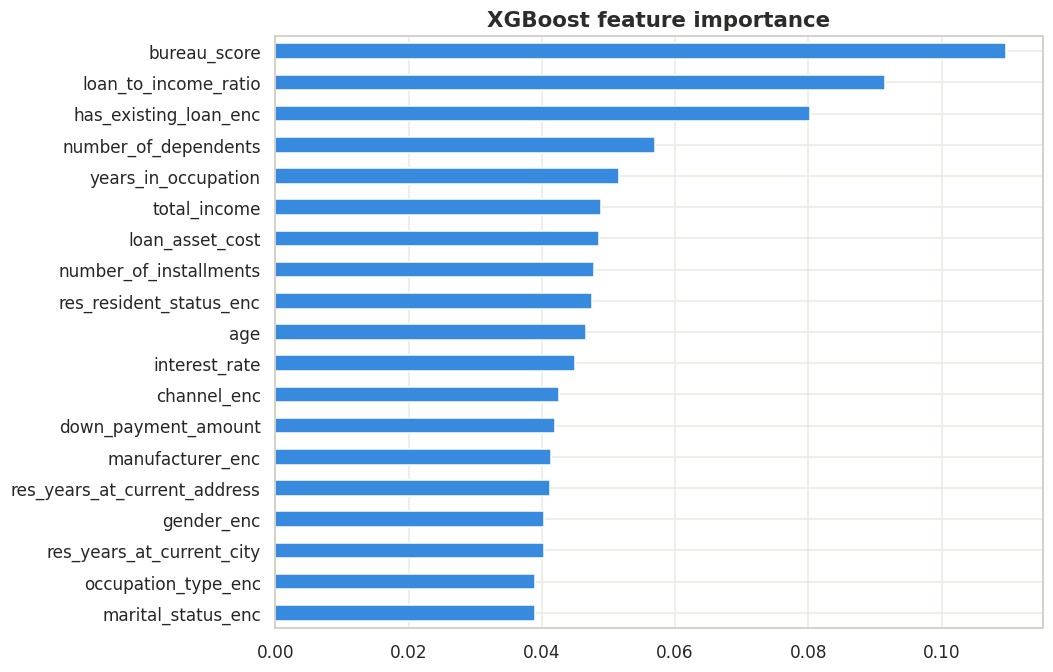


✓ Run ID: 2e01c42a234947e5a4a63afc9d354d11


In [21]:
# ── Block 12: XGBoost training with MLflow tracking ─────────────────────
import mlflow
import mlflow.xgboost
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
)
import pickle, os

MLFLOW_URI = "./mlruns"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("motorcycle-loan-default")

THRESHOLD = 0.35

PARAMS = {
    "n_estimators":     500,
    "max_depth":        4,
    "learning_rate":    0.03,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "scale_pos_weight": imbalance_ratio,
    "eval_metric":      "auc",
    "random_state":     42,
    "n_jobs":           -1,
}

with mlflow.start_run(run_name="xgboost_v1_final") as run:
    RUN_ID = run.info.run_id

    model = xgb.XGBClassifier(**PARAMS)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred       = (y_pred_proba >= THRESHOLD).astype(int)

    metrics = {
        "auc_roc":   roc_auc_score(y_test, y_pred_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "accuracy":  accuracy_score(y_test, y_pred),
    }

    print("── Model metrics ──")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")

    mlflow.log_params(PARAMS)
    mlflow.log_metrics(metrics)
    mlflow.log_param("threshold", THRESHOLD)
    mlflow.log_param("dataset", "ph_synthetic_v1")
    mlflow.xgboost.log_model(model, artifact_path="model")

    enc_path = "figures/encoders.pkl"
    with open(enc_path, "wb") as f:
        pickle.dump(encoders, f)
    mlflow.log_artifact(enc_path)

    # confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Repaid", "Default"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion matrix — threshold {THRESHOLD}")
    cm_path = "figures/08_confusion_matrix.png"
    plt.savefig(cm_path); plt.show()
    mlflow.log_artifact(cm_path)

    # feature importance
    fi = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    fig, ax = plt.subplots(figsize=(9, 7))
    fi.plot(kind="barh", ax=ax, color=BRAND["accent"], edgecolor="white")
    ax.set_title("XGBoost feature importance")
    fi_path = "figures/09_feature_importance.png"
    plt.savefig(fi_path); plt.show()
    mlflow.log_artifact(fi_path)

    print(f"\n✓ Run ID: {RUN_ID}")

In [22]:
# ── Block 13: Register model ─────────────────────────────────────────────
from mlflow.tracking import MlflowClient

MODEL_NAME = "motorcycle-loan-model"
client = MlflowClient(tracking_uri=MLFLOW_URI)
registered = mlflow.register_model(f"runs:/{RUN_ID}/model", MODEL_NAME)
print(f"✓ Registered: {MODEL_NAME} v{registered.version}")
print(f"✓ Run ID: {RUN_ID}")

Registered model 'motorcycle-loan-model' already exists. Creating a new version of this model...
2026/06/04 21:15:13 WARNING mlflow.tracking._model_registry.fluent: Run with id 2e01c42a234947e5a4a63afc9d354d11 has no artifacts at artifact path 'model', registering model based on models:/m-2785b285af564d1f9abcf01b261f9d8d instead


✓ Registered: motorcycle-loan-model v9
✓ Run ID: 2e01c42a234947e5a4a63afc9d354d11


Created version '9' of model 'motorcycle-loan-model'.


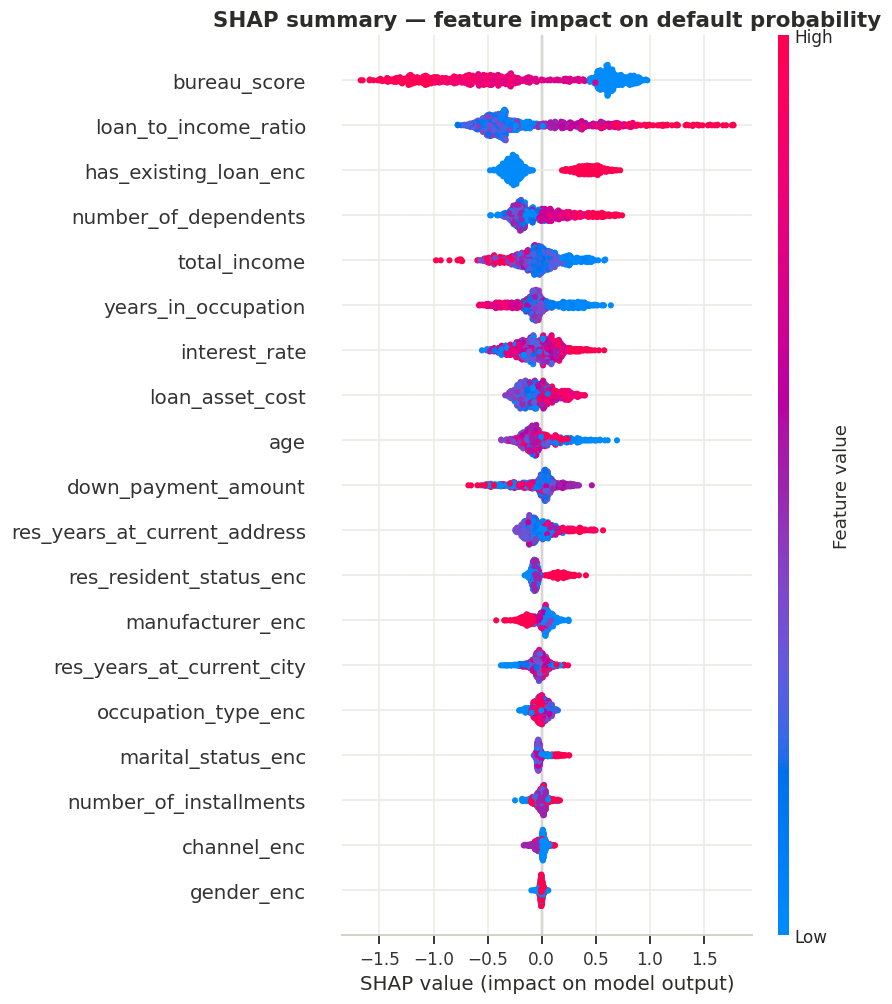

✓ Saved figures/10_shap_summary.png

Mang Tony default probability: 14.77%
Decision (0.35 threshold): APPROVED


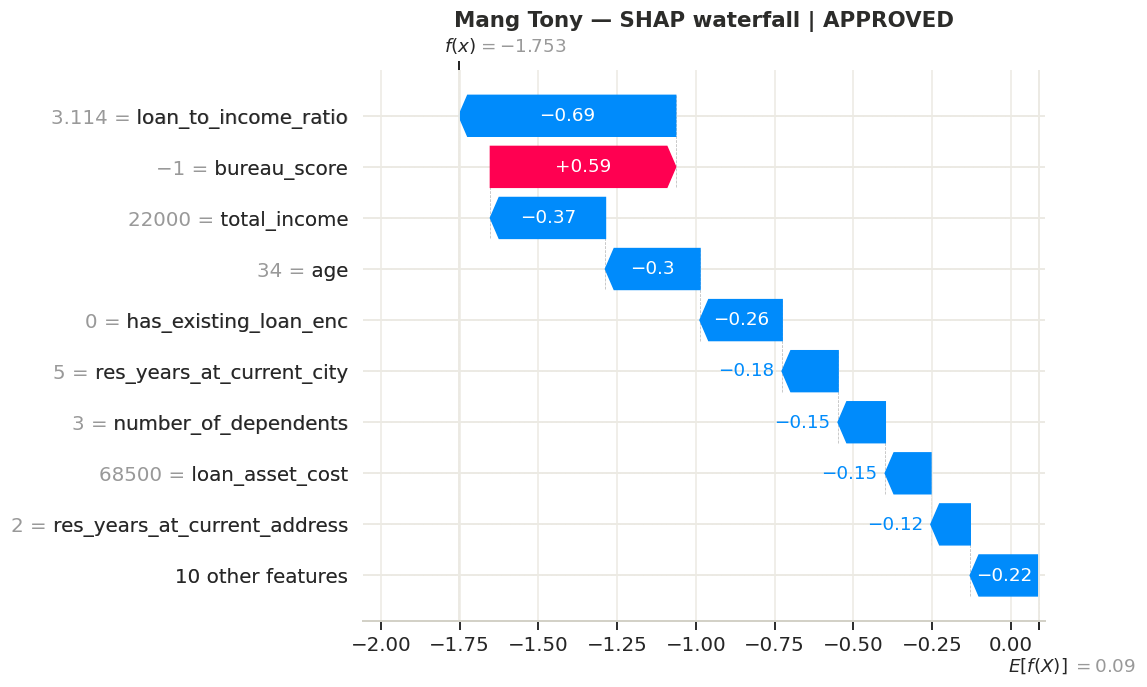

✓ Saved figures/11_mang_tony_waterfall.png


In [23]:
# ── Block 14: SHAP explainability ───────────────────────────────────────
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP summary — feature impact on default probability")
shap_summary_path = "figures/10_shap_summary.png"
plt.savefig(shap_summary_path, bbox_inches="tight")
plt.show()
print(f"✓ Saved {shap_summary_path}")

# Mang Tony
mang_tony_raw = {
    "bureau_score": -1, "down_payment_amount": 9000, "interest_rate": 14.99,
    "loan_asset_cost": 68500, "age": 34, "number_of_installments": 24,
    "total_income": 22000, "years_in_occupation": 6, "number_of_dependents": 3,
    "res_years_at_current_city": 5, "res_years_at_current_address": 2,
    "gender": "Male", "occupation_type": "Tricycle/Jeepney Driver",
    "marital_status": "Married", "res_resident_status": "Living with Parents",
    "has_existing_loan": "No", "manufacturer": "Honda", "channel": "DEALER",
}

mang_tony_enc = {
    "bureau_score": -1, "down_payment_amount": 9000, "interest_rate": 14.99,
    "loan_asset_cost": 68500, "age": 34, "number_of_installments": 24,
    "total_income": 22000, "years_in_occupation": 6, "number_of_dependents": 3,
    "res_years_at_current_city": 5, "res_years_at_current_address": 2,
    "loan_to_income_ratio": 68500 / 22000,
}
for col in encode_cols:
    le = encoders[col]
    val = mang_tony_raw[col]
    mang_tony_enc[col + "_enc"] = int(
        le.transform([val])[0] if val in le.classes_ else 0
    )

mang_tony_df = pd.DataFrame(
    [[mang_tony_enc[c] for c in FEATURE_COLS]], columns=FEATURE_COLS
)

tony_prob = model.predict_proba(mang_tony_df)[0][1]
tony_pred = "NEEDS REVIEW" if tony_prob >= THRESHOLD else "APPROVED"
tony_shap = explainer.shap_values(mang_tony_df)

print(f"\nMang Tony default probability: {tony_prob:.2%}")
print(f"Decision ({THRESHOLD} threshold): {tony_pred}")

shap.plots.waterfall(
    shap.Explanation(
        values=tony_shap[0],
        base_values=explainer.expected_value,
        data=mang_tony_df.iloc[0].values,
        feature_names=FEATURE_COLS,
    ),
    show=False,
)
plt.title(f"Mang Tony — SHAP waterfall | {tony_pred}")
waterfall_path = "figures/11_mang_tony_waterfall.png"
plt.savefig(waterfall_path, bbox_inches="tight")
plt.show()
print(f"✓ Saved {waterfall_path}")

In [24]:
# ── Block 15: Save artifacts for FastAPI ────────────────────────────────
import json, pickle, os

os.makedirs("models", exist_ok=True)

model.save_model("models/xgb_motorcycle_loan_v1.json")
print("✓ models/xgb_motorcycle_loan_v1.json")

with open("models/encoders_v1.pkl", "wb") as f:
    pickle.dump(encoders, f)
print("✓ models/encoders_v1.pkl")

with open("models/feature_cols_v1.pkl", "wb") as f:
    pickle.dump(FEATURE_COLS, f)
print("✓ models/feature_cols_v1.pkl")

with open("models/threshold_v1.pkl", "wb") as f:
    pickle.dump(THRESHOLD, f)
print("✓ models/threshold_v1.pkl")

with open("models/sample_prediction.json", "w") as f:
    json.dump({
        "input": mang_tony_raw,
        "default_probability": round(float(tony_prob), 4),
        "decision": tony_pred,
        "threshold_used": THRESHOLD,
        "model_version": "v1",
    }, f, indent=2)
print("✓ models/sample_prediction.json")

print(f"""
── Handoff to your friend ──
models/xgb_motorcycle_loan_v1.json  — the model
models/encoders_v1.pkl              — label encoders (19 features)
models/feature_cols_v1.pkl          — feature order (critical!)
models/threshold_v1.pkl             — decision threshold: {THRESHOLD}
models/sample_prediction.json       — test this in FastAPI first
mlruns/                             — mount this in Docker for MLflow UI
Run ID: {RUN_ID}
AUC:    {metrics['auc_roc']:.4f}
Recall: {metrics['recall']:.4f}
""")

✓ models/xgb_motorcycle_loan_v1.json
✓ models/encoders_v1.pkl
✓ models/feature_cols_v1.pkl
✓ models/threshold_v1.pkl
✓ models/sample_prediction.json

── Handoff to your friend ──
models/xgb_motorcycle_loan_v1.json  — the model
models/encoders_v1.pkl              — label encoders (19 features)
models/feature_cols_v1.pkl          — feature order (critical!)
models/threshold_v1.pkl             — decision threshold: 0.35
models/sample_prediction.json       — test this in FastAPI first
mlruns/                             — mount this in Docker for MLflow UI
Run ID: 2e01c42a234947e5a4a63afc9d354d11
AUC:    0.7698
Recall: 0.7696



In [25]:
# ── Test: load artifacts and score Mang Tony ────────────────────────────
import xgboost as xgb
import pickle, json
import pandas as pd

# Load everything fresh (simulating what FastAPI will do)
test_model = xgb.XGBClassifier()
test_model.load_model("models/xgb_motorcycle_loan_v1.json")

with open("models/encoders_v1.pkl", "rb") as f:
    test_encoders = pickle.load(f)

with open("models/feature_cols_v1.pkl", "rb") as f:
    test_features = pickle.load(f)

with open("models/threshold_v1.pkl", "rb") as f:
    test_threshold = pickle.load(f)

print("✓ All artifacts loaded")
print(f"  Features: {len(test_features)}")
print(f"  Threshold: {test_threshold}")
print(f"  Encoders: {list(test_encoders.keys())}")

# Mang Tony's raw input (what FastAPI will receive)
mang_tony = {
    "bureau_score": -1,
    "down_payment_amount": 9000,
    "interest_rate": 14.99,
    "loan_asset_cost": 68500,
    "age": 34,
    "number_of_installments": 24,
    "total_income": 22000,
    "years_in_occupation": 6,
    "number_of_dependents": 3,
    "res_years_at_current_city": 5,
    "res_years_at_current_address": 2,
    "gender": "Male",
    "occupation_type": "Tricycle/Jeepney Driver",
    "marital_status": "Married",
    "res_resident_status": "Living with Parents",
    "has_existing_loan": "No",
    "manufacturer": "Honda",
    "channel": "DEALER",
}

# Encode (same logic FastAPI will use)
encode_cols = [
    "gender", "occupation_type", "marital_status",
    "res_resident_status", "has_existing_loan", "manufacturer", "channel",
]

row = {
    "bureau_score":                 mang_tony["bureau_score"],
    "down_payment_amount":          mang_tony["down_payment_amount"],
    "interest_rate":                mang_tony["interest_rate"],
    "loan_asset_cost":              mang_tony["loan_asset_cost"],
    "age":                          mang_tony["age"],
    "number_of_installments":       mang_tony["number_of_installments"],
    "total_income":                 mang_tony["total_income"],
    "years_in_occupation":          mang_tony["years_in_occupation"],
    "number_of_dependents":         mang_tony["number_of_dependents"],
    "res_years_at_current_city":    mang_tony["res_years_at_current_city"],
    "res_years_at_current_address": mang_tony["res_years_at_current_address"],
    "loan_to_income_ratio":         mang_tony["loan_asset_cost"] / mang_tony["total_income"],
}
for col in encode_cols:
    le = test_encoders[col]
    val = mang_tony[col]
    row[col + "_enc"] = int(le.transform([val])[0] if val in le.classes_ else 0)

input_df = pd.DataFrame([[row[c] for c in test_features]], columns=test_features)

# Score
prob = test_model.predict_proba(input_df)[0][1]
decision = "NEEDS REVIEW" if prob >= test_threshold else "APPROVED"

print(f"\n── Mang Tony test result ──")
print(f"  Default probability: {prob:.2%}")
print(f"  Decision:            {decision}")
print(f"  Threshold used:      {test_threshold}")

# Compare with saved sample
with open("models/sample_prediction.json") as f:
    saved = json.load(f)
print(f"\n── Match with saved sample ──")
print(f"  Saved probability:   {saved['default_probability']:.2%}")
print(f"  Saved decision:      {saved['decision']}")
match = abs(prob - saved['default_probability']) < 0.001
print(f"  Match: {'✓ PASS' if match else '✗ FAIL — something changed'}")

✓ All artifacts loaded
  Features: 19
  Threshold: 0.35
  Encoders: ['gender', 'occupation_type', 'marital_status', 'res_resident_status', 'has_existing_loan', 'manufacturer', 'channel']

── Mang Tony test result ──
  Default probability: 14.77%
  Decision:            APPROVED
  Threshold used:      0.35

── Match with saved sample ──
  Saved probability:   14.77%
  Saved decision:      APPROVED
  Match: ✓ PASS
